In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
# Reading the data file from data folder
data = pd.read_excel("data/Acceleration with g.xlsx")


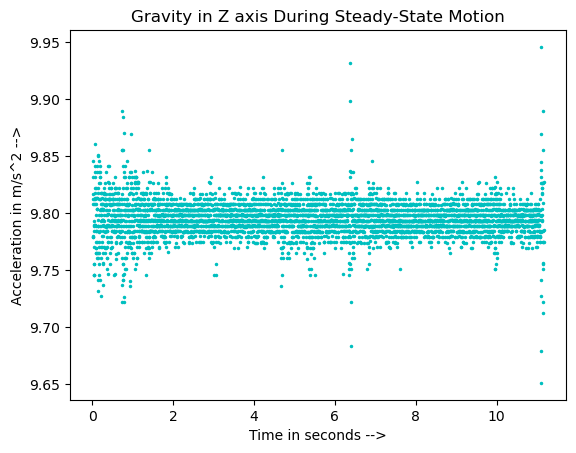

In [100]:
# plotting the gravity in z axis from our data

fig, ax = plt.subplots()
ax.errorbar(data['Time (s)'], data.iloc[:, -1], color="c",fmt='.', markersize=3)
ax.set_title("Gravity in Z axis During Steady-State Motion")
ax.set_xlabel("Time in seconds -->")
ax.set_ylabel("Acceleration in m/s^2 -->")
pass

#### We now create a distribution of our data to see our most frequent data instance for gravity meausurment

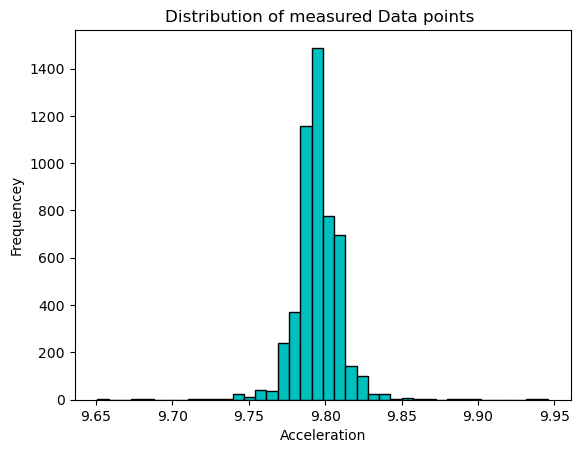

In [18]:


plt.hist(data.iloc[:, -1], bins=40, color="c",edgecolor='black')
plt.title("Distribution of measured Data points ")
plt.xlabel("Acceleration")
plt.ylabel("Frequencey")
pass

In [106]:
# Getting the mean, standard deviation and standard error

mean = data.iloc[:, -1].mean()     # The mean of each gravity measurment
std = data.iloc[:, -1].std()
mean_std = std / np.sqrt(len(data.iloc[:, 0]))
print(f"Mean = {mean:.3g}\nStandard deviation = {std:.1e}\nMean of standard deviation = {mean_std:.1e}")


Mean = 9.8
Standard deviation = 1.5e-02
Mean of standard deviation = 2.1e-04


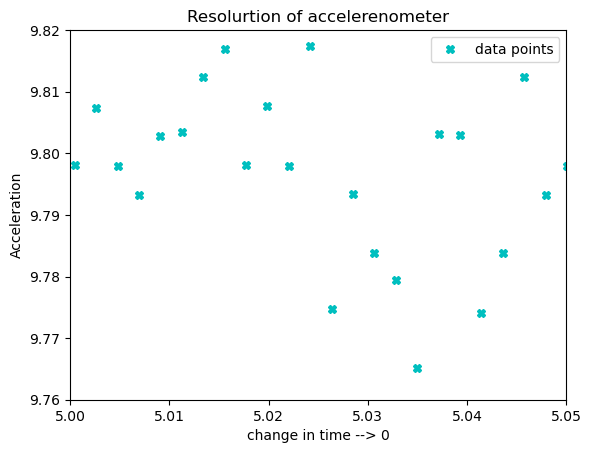

In [108]:
# Plotting the resolution of the accelerenometer

plt.plot(data['Time (s)'], data.iloc[:, -1],'X', color="c" )
plt.xlim(5,5.05)
plt.ylim(9.76,9.82)
plt.xlabel("change in time --> 0")
plt.ylabel("Acceleration")
plt.title("Resolurtion of accelerenometer")
resolution = sorted(data.iloc[:, -1])
resolution = [resolution[i+1] - resolution[i] for i in range(len(resolution) - 1)]
resolution = min(resolution)
plt.legend(["data points"])
pass

#### Statistical Summury
$$
\begin{aligned}
\text{Mean} & = 9.80 \\
\text{Standard Deviation} & = 1.5 \times 10^{-2} \\
\text{Mean of Standard Deviation} & = 2.0 \times 10^{-4}
\end{aligned}
$$


In [111]:
# Grouping the data set into 20 bins cummulatively

bins = [data.iloc[: i * int(len(data) / 20), -1] for i in range(1, 21)]           
print(len(bins))

20


In [113]:
## calculating the mean and standard deviation 
## for each groups 

 # The mean of each groups
mean_list = [np.mean(bins[i]) for i in range(len(bins))]      

# The standard deviation of each groups 
std_list = [np.std(bins[i]) for i in range(len(bins))] 

# The standard error of each groups
std_mean_list = [std_list[i] / np.sqrt(len(bins[i])) for i in range(len(std_list))]

# length of each group
num_measurment = [len(group) for group in bins]



### The dominant souce of uncertainity is the unintended contact forces applied to our phone. We can see from the first graph that the measurments are most uncertain at the start and end of our measurments which happens to be the time we interact with our phone.

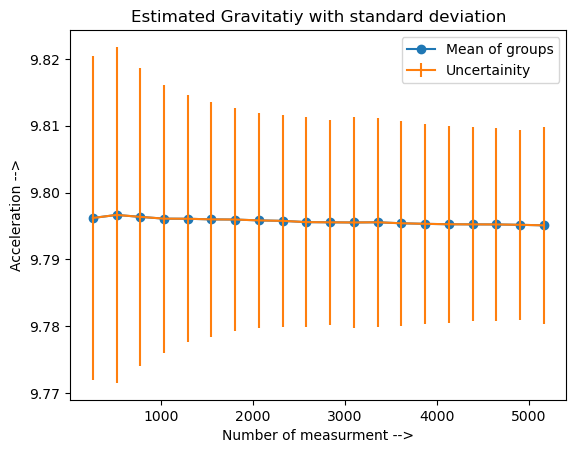

In [116]:
fig, ax = plt.subplots()
ax.plot(num_measurment, mean_list, marker='o', label="Mean of groups")
ax.errorbar(num_measurment, mean_list, yerr=std_list, label = "Uncertainity")
ax.set_title("Estimated Gravitatiy with standard deviation")
ax.set_xlabel("Number of measurment -->")
ax.set_ylabel("Acceleration -->")
ax.legend()
pass

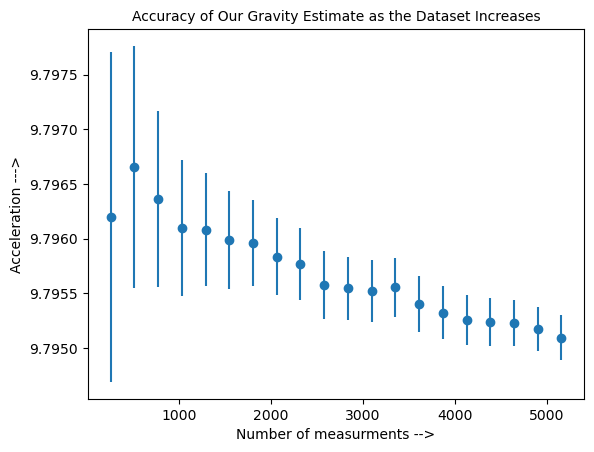

In [118]:

plt.errorbar(num_measurment, mean_list, yerr=std_mean_list, fmt = 'o', )
plt.title("Accuracy of Our Gravity Estimate as the Dataset Increases", fontsize=10)
plt.xlabel("Number of measurments -->")
plt.ylabel("Acceleration --->")
pass

# Comparrison to the accepted value

### Our results compare very well with the accepted value for gravity in the city of Baltimore maryland which is around 9.8 because our estimate for gravity when using all our data points was also 9.8 and the accepted value of gravity lies between our estimage and its associated uncertainity.

